In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)


TensorFlow: 2.15.0


In [2]:
max_features = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    
    num_words=max_features
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("Positive:", np.sum(y_train))
print("Negative:", len(y_train)-np.sum(y_train))

Training Shape : (25000,)
Testing Shape  : (25000,)
Positive: 12500
Negative: 12500


In [3]:
max_len = 500

X_train = pad_sequences(
    X_train,
    maxlen=max_len,
    padding="pre",
    truncating="pre"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_len,
    padding="pre",
    truncating="pre"
)

print(X_train.shape)
print(X_test.shape)

(25000, 500)
(25000, 500)


In [4]:
print(X_train.dtype)
print(X_train.min())
print(X_train.max())


print(np.unique(y_train))

print(X_train[0][-20:])

int32
0
9999
[0 1]
[  65   16   38 1334   88   12   16  283    5   16 4472  113  103   32
   15   16 5345   19  178   32]


In [5]:
model = Sequential()

model.add(
    Embedding(
        input_dim=max_features,
        output_dim=128,
        input_length=max_len
    )
)

model.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model.add(Dropout(0.5))

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(Dropout(0.3))

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 128)          1280000   
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1419905 (5.42 MB)
Trainable params: 14199

In [6]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Callbacks

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "simple_rnn_imdb.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [8]:
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

print(np.min(X_train))
print(np.max(X_train))

print(np.unique(y_train))
print(X_train[0][:20])
print(y_train[0])

(25000, 500)
(25000,)
int32
int64
0
9999
[0 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
1


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/10


313/313 [==============================] - ETA: 0s - loss: 0.4902 - accuracy: 0.7533
Epoch 1: val_accuracy improved from -inf to 0.84780, saving model to simple_rnn_imdb.h5
313/313 [==============================] - 972s 3s/step - loss: 0.4902 - accuracy: 0.7533 - val_loss: 0.3527 - val_accuracy: 0.8478
Epoch 2/10


c:\Users\Administrator\miniconda3\envs\ienv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - ETA: 0s - loss: 0.2555 - accuracy: 0.9008
Epoch 2: val_accuracy improved from 0.84780 to 0.87000, saving model to simple_rnn_imdb.h5
313/313 [==============================] - 2084s 7s/step - loss: 0.2555 - accuracy: 0.9008 - val_loss: 0.3080 - val_accuracy: 0.8700
Epoch 3/10
313/313 [==============================] - ETA: 0s - loss: 0.2076 - accuracy: 0.9219
Epoch 3: val_accuracy did not improve from 0.87000
313/313 [==============================] - 1948s 6s/step - loss: 0.2076 - accuracy: 0.9219 - val_loss: 0.3733 - val_accuracy: 0.8320
Epoch 4/10
313/313 [==============================] - ETA: 0s - loss: 0.2604 - accuracy: 0.8938
Epoch 4: val_accuracy did not improve from 0.87000
313/313 [==============================] - 2660s 9s/step - loss: 0.2604 - accuracy: 0.8938 - val_loss: 0.5061 - val_accuracy: 0.8548
Epoch 5/10
313/313 [==============================] - ETA: 0s - loss: 0.1477 - accuracy: 0.9477Restoring model weights from the end

In [10]:
# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

782/782 [==============================] - 100s 128ms/step - loss: 0.3218 - accuracy: 0.8649

Test Loss     : 0.3218
Test Accuracy : 86.49%


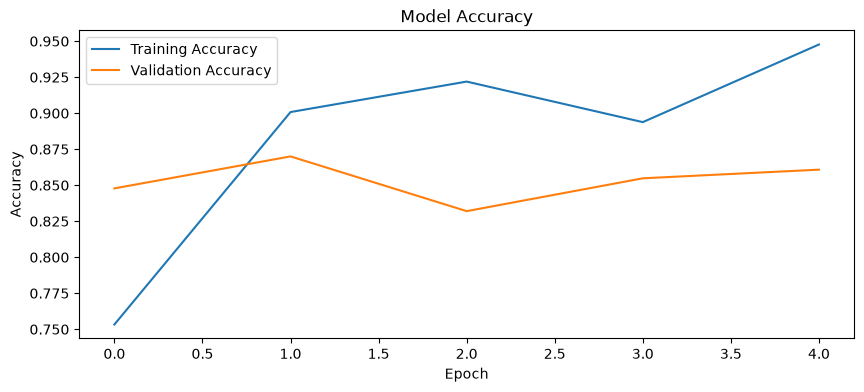

In [11]:
# Plot Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

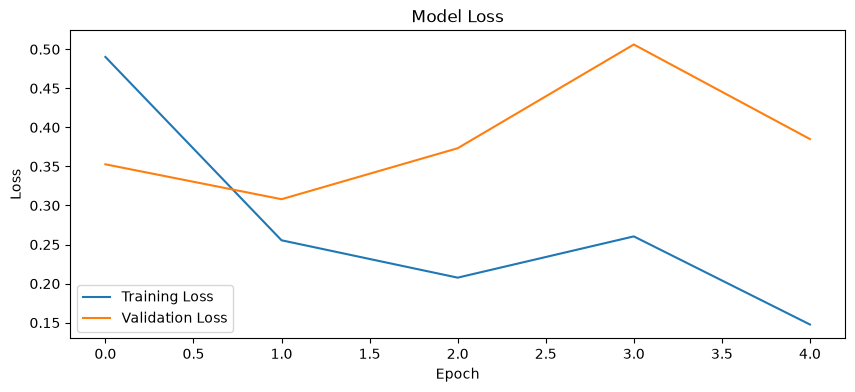

In [12]:
# Plot Loss

plt.figure(figsize=(10,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()